# Title + Objective (Markdown)

Goal: insight extraction + plots saved into reports/

# EcoType — Exploratory Data Analysis (EDA)

## Objective
This notebook explores the engineered forest cover dataset to understand:

- class balance of the target
- feature distributions and summary statistics
- correlation structure among numeric features
- how top features relate to the target
- possible outlier effects
- possible leakage risks before modeling

## Outputs
This notebook saves:

- EDA plots to `reports/figures/eda/`
- `EDA_Report.md` to `reports/`

# Imports + Paths

Load dataset used for EDA (cleaned or processed)

Print shape + dtypes

In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
warnings.filterwarnings("ignore")

plt.style.use("default")
sns.set_theme(style = "whitegrid")

In [3]:
project_root = Path.cwd().resolve().parent
data_interim_dir = project_root/"data"/"interim"
data_processed_dir = project_root/"data"/"processed"
reports_dir = project_root/"reports"
figures_dir = reports_dir/"figures"

eda_report_file = reports_dir/"eda_report.md"

random_state = 42
target_candidates = ["cover_type", "target", "class", "label"]

# Helper Functions

In [4]:
def find_target_column(df: pd.DataFrame, candidates: list[str] | None = None):
    candidates = candidates or target_candidates
    lowered = {col.lower(): col for col in df.columns}

    for cand in candidates:
        if cand.lower() in lowered:
            return lowered[cand.lower()]

    raise ValueError(
        f"Target column not found. Checked candidates: {candidates}."
        f"Available columns: {list(df.columns)}"
    )

In [5]:
def load_best_available_dataset():
    candidate_files = [
        data_processed_dir/"Forest_cover_engineered.csv",
        data_processed_dir/"forest_cover_processed.csv",
        data_interim_dir/"forest_cover_cleaned.csv",
        data_interim_dir/"forest_cover_interim"
    ]

    for file in candidate_files:
        if file.exists():
            df = pd.read_csv(file)
            return df, file

    raise FileNotFoundError(
        "No suitable dataset found for EDA."
        "Expected one of: "
        + ", ".join(str(p) for p in candidate_files)
    )

In [6]:
def split_feature_types(df: pd.DataFrame, target_col: str):
    feature_cols = [col for col in df.columns if col != target_col]
    numeric_cols = df[feature_cols].select_dtypes(include = ["number"]).columns.tolist()
    categorical_cols = [col for col in feature_cols if col not in numeric_cols]
    return numeric_cols, categorical_cols

In [7]:
def save_plot(fig, filename: str):
    out_path = figures_dir/filename
    fig.tight_layout()
    fig.savefig(out_path, dpi = 300, bbox_inches = "tight")
    plt.close(fig)
    return out_path

In [8]:
def is_binary_or_indicator(series: pd.Series):
    vals = series.dropna().unique()
    return len(vals) <= 2

In [9]:
def compute_iqr_outlier_summary(df: pd.DataFrame, numeric_cols: list[str]):
    rows = []
    for col in numeric_cols:
        s = df[col].dropna()
        if s.empty:
            continue

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        if iqr == 0:
            outliers = pd.Series(dtype = float)
            pct = 0.0
        else:
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            outliers = s[(s < lower) | (s > upper)]
            pct = (len(outliers) / len(s)) * 100

        rows.append(
            {
                "features": col,
                "q1": q1,
                "q3": q3,
                "iqr": iqr,
                "outlier_count": len(outliers),
                "outlier_pct": round(pct, 2)
            }
        )

    out_df = pd.DataFrame(rows).sort_values("outlier_pct", ascending = False).reset_index(drop = True)
    return out_df

In [10]:
def make_markdown_table(df: pd.DataFrame, max_rows: int = 10) -> str:
    if df.empty:
        return "_No rows available._"
    return df.head(max_rows).to_markdown(index=False)

# Load Cleaned/Processed Data (Code)

In [11]:
df, source_file = load_best_available_dataset()
target_col = find_target_column(df)

numeric_cols, categorical_cols = split_feature_types(df, target_col)

print("Loaded file:", source_file)
print("Shape:", df.shape)
print("Target Column:", target_col)
print("Numeric Columns:", len(numeric_cols))
print("Categorical Columns:", len(categorical_cols))

df.head()

Loaded file: F:\DATA SCIENCE\Projects\Forest Cover Type Prediction\data\processed\Forest_cover_engineered.csv
Shape: (145890, 26)
Target Column: cover_type
Numeric Columns: 25
Categorical Columns: 0


,elevation,aspect,slope,horizontal_distance_to_hydrology,vertical_distance_to_hydrology,horizontal_distance_to_roadways,hillshade_9am,hillshade_noon,hillshade_3pm,horizontal_distance_to_fire_points,...,vertical_distance_to_hydrology_abs,hillshade_mean,hillshade_range,hillshade_std,elevation_slope_interaction,elevation_slope_ratio,road_fire_gap,road_fire_ratio,hydrology_fire_ratio,hydrology_road_ratio
0,2596,51,3,258,0,510,221,232,148,6279,...,0,200.333333,84,45.654500,7788,865.333045,5769,0.081223,0.041089,0.505882
1,2590,56,2,212,-6,390,220,235,151,6225,...,6,202.000000,84,44.799554,5180,1294.999353,5835,0.062651,0.034056,0.543590
2,2804,139,9,268,65,3180,234,238,135,6121,...,65,202.333333,103,58.346665,25236,311.555521,2941,0.519523,0.043784,0.084277
3,2785,155,18,242,118,3090,238,238,122,6211,...,118,199.333333,116,66.972631,50130,154.722214,3121,0.497504,0.038963,0.078317
4,2595,45,2,153,-1,391,220,234,150,6172,...,1,201.333333,84,45.003704,5190,1297.499351,5781,0.063351,0.024789,0.391304


In [12]:
basic_info = {
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
    "target_column": target_col,
    "numeric_feature_count": len(numeric_cols),
    "categorical_feature_count": len(categorical_cols),
    "missing_cells_total": int(df.isna().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
}

basic_info

{'rows': 145890,
 'columns': 26,
 'target_column': 'cover_type',
 'numeric_feature_count': 25,
 'categorical_feature_count': 0,
 'missing_cells_total': 0,
 'duplicate_rows': 0}

# Class Distribution (Code)

Counts

%

Plot bar chart

Save plot

A classification project must first verify whether the target classes are balanced or imbalanced.
This affects:
- train/test split strategy
- evaluation metrics
- model choice
- possible class weighting

In [13]:
class_counts = df[target_col].value_counts().sort_index()
class_pct = (class_counts / class_counts.sum() * 100).round(2)

fig, ax = plt.subplots(figsize = (10, 5))
sns.barplot(x = class_counts.index.astype(str), y = class_counts.values, ax = ax)
ax.set_title("Class Distribution of Cover Type")
ax.set_xlabel("Class")
ax.set_ylabel("Count")

for i, v in enumerate(class_counts.values):
    ax.text(i, v, f"{v}", ha = "center", va = "bottom", fontsize = 9)

class_dist_plot = save_plot(fig, "class_distribution_bar.png")
class_dist_plot

WindowsPath('F:/DATA SCIENCE/Projects/Forest Cover Type Prediction/reports/figures/class_distribution_bar.png')

In [14]:
class_distribution_df = pd.DataFrame({
    "class": class_counts.index,
    "count": class_counts.values,
    "percentage": class_pct.values,
})

class_distribution_df

,class,count,percentage
0,Aspen,3069,2.10
1,Cottonwood/Willow,2160,1.48
2,Douglas-fir,2160,1.48
3,Krummholz,2160,1.48
4,Lodgepole Pine,103071,70.65
5,Ponderosa Pine,2160,1.48
6,Spruce/Fir,31110,21.32


# Summary Statistics (Code)

describe().T

Save summary table

This section captures central tendency, spread, and range for numeric variables.
It helps reveal:
- scale differences
- skewness clues
- suspicious min/max values
- variables needing careful interpretation

In [15]:
summary_stats = df[numeric_cols].describe().T
summary_stats["median"] = df[numeric_cols].median()
summary_stats["skew"] = df[numeric_cols].skew(numeric_only=True)
summary_stats["kurtosis"] = df[numeric_cols].kurt(numeric_only=True)

summary_stats = summary_stats[
    ["count", "mean", "std", "min", "25%", "median", "50%", "75%", "max", "skew", "kurtosis"]
].sort_values("std", ascending=False)

summary_stats.head(15)

,count,mean,std,min,25%,median,50%,75%,max,skew,kurtosis
elevation_slope_ratio,145890.0,4.860878e+06,1.189299e+08,43.499999,187.374988,263.909067,263.909067,388.624951,3.379000e+09,24.500997,600.098522
road_fire_ratio,145890.0,9.285934e+04,1.815868e+07,0.000000,0.676161,1.066110,1.066110,1.744899,4.818000e+09,244.117468,62643.458634
hydrology_fire_ratio,145890.0,9.000067e+03,1.532743e+06,0.000000,0.033800,0.079933,0.079933,0.157735,3.900000e+08,193.873821,41127.896601
hydrology_road_ratio,145890.0,1.795990e+03,4.376211e+05,0.000000,0.033094,0.070187,0.070187,0.125995,1.240000e+08,261.163656,69757.660080
elevation_slope_interaction,145890.0,3.407287e+04,1.759609e+04,0.000000,21189.000000,31966.500000,31966.500000,44175.000000,1.668960e+05,0.811074,1.065621
horizontal_distance_to_fire_points,145890.0,3.044958e+03,1.761882e+03,0.000000,1608.000000,2713.000000,2713.000000,4478.000000,7.173000e+03,0.365249,-0.967014
horizontal_distance_to_roadways,145890.0,3.313828e+03,1.687780e+03,0.000000,1848.000000,3420.000000,3420.000000,4673.000000,7.117000e+03,-0.058240,-1.066885
road_fire_gap,145890.0,1.619414e+03,1.321933e+03,0.000000,566.000000,1183.500000,1183.500000,2481.000000,6.017000e+03,0.868522,-0.250112
elevation,145890.0,2.874459e+03,2.108013e+02,1863.000000,2747.000000,2909.000000,2909.000000,3004.000000,3.849000e+03,-0.664497,1.608628
hydrology_distance,145890.0,2.559178e+02,1.945783e+02,0.000000,98.234414,216.667949,216.667949,368.069287,1.356940e+03,0.973905,0.862716


In [16]:
summary_stats_file = reports_dir / "summary_stats.csv"
summary_stats.to_csv(summary_stats_file)
summary_stats_file

WindowsPath('F:/DATA SCIENCE/Projects/Forest Cover Type Prediction/reports/summary_stats.csv')

# Univariate Distributions (Code)

Loop numeric columns

Histograms + boxplots

Save figures

# Correlation Heatmap (Code)

correlation matrix

heatmap plot

save figure

In [17]:
corr_df = df[numeric_cols].copy()

# remove constant columns if any
constant_cols = [col for col in corr_df.columns if corr_df[col].nunique(dropna = False) <= 1]
corr_df = corr_df.drop(columns = constant_cols, errors = "ignore")

corr_matrix = corr_df.corr(numeric_only = True)

Text(0.5, 1.0, 'Correlation Heatmap(Numeric Features)')

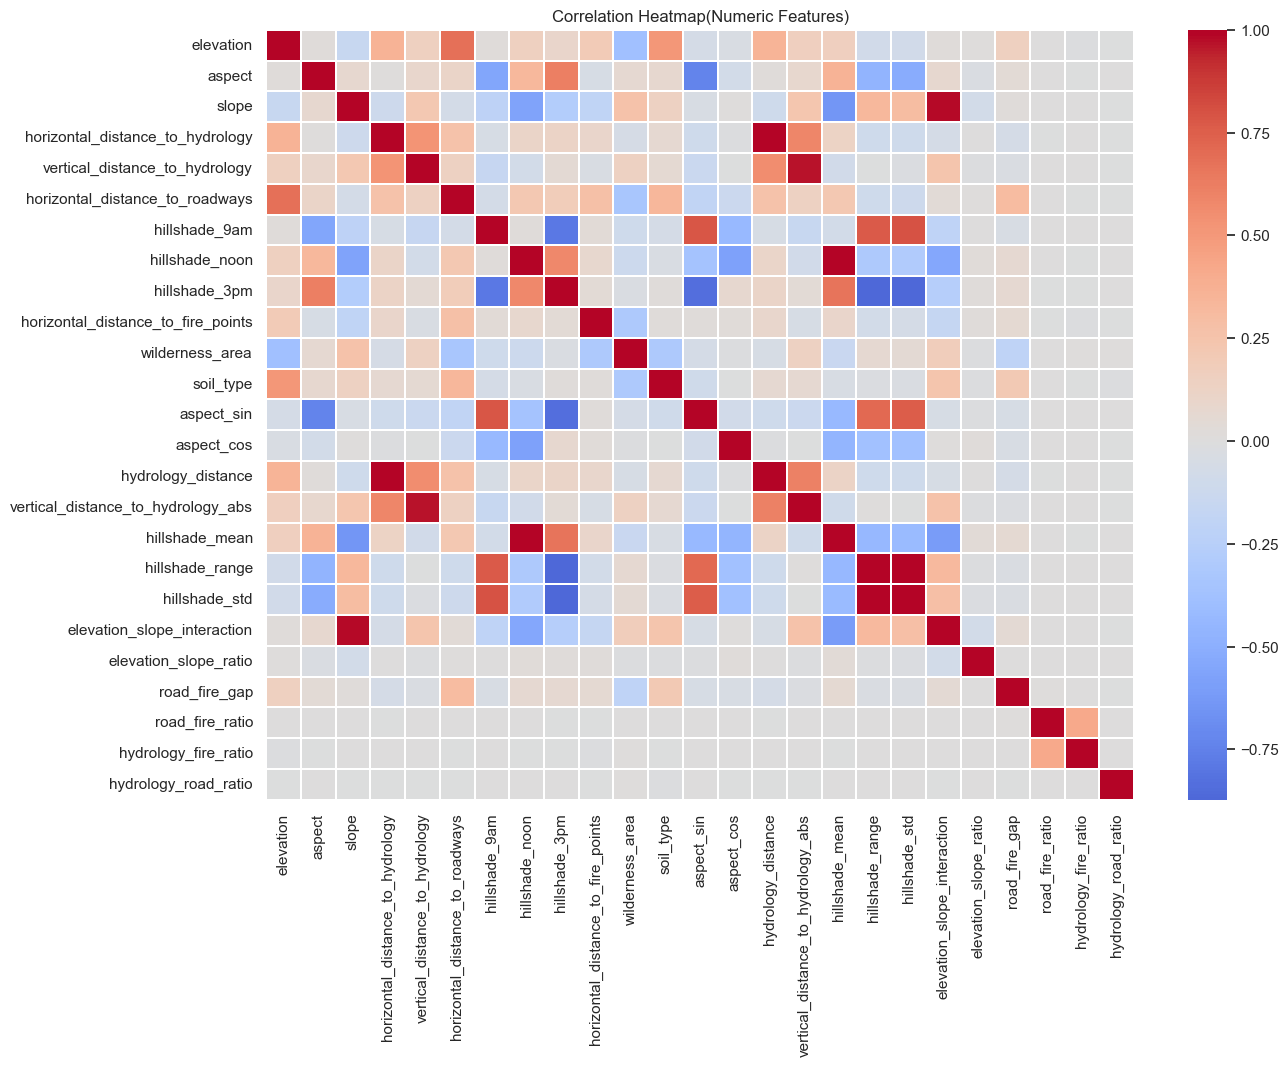

In [18]:
fig, ax = plt.subplots(figsize = (14, 10))
sns.heatmap(
    corr_matrix,
    cmap = "coolwarm",
    center = 0,
    linewidth = 0.3,
    cbar = True,
    ax = ax
)

ax.set_title("Correlation Heatmap(Numeric Features)")

In [19]:
corr_plot = save_plot(fig, "correlation_heatmap.png")
corr_plot

WindowsPath('F:/DATA SCIENCE/Projects/Forest Cover Type Prediction/reports/figures/correlation_heatmap.png')

In [20]:
# Top Correlated Pairs
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k = 1).astype(bool)).stack().reset_index()
)
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()

top_corr_pairs = corr_pairs.sort_values("abs_correlation", ascending = False).reset_index(drop = True)
top_corr_pairs.head(15)

,feature_1,feature_2,correlation,abs_correlation
0,horizontal_distance_to_hydrology,hydrology_distance,0.999412,0.999412
1,hillshade_range,hillshade_std,0.992695,0.992695
2,hillshade_noon,hillshade_mean,0.985755,0.985755
3,slope,elevation_slope_interaction,0.981452,0.981452
4,vertical_distance_to_hydrology,vertical_distance_to_hydrology_abs,0.963914,0.963914
5,hillshade_3pm,hillshade_std,-0.872872,0.872872
6,hillshade_3pm,hillshade_range,-0.867466,0.867466
7,hillshade_3pm,aspect_sin,-0.836382,0.836382
8,hillshade_9am,hillshade_std,0.797403,0.797403
9,hillshade_9am,hillshade_3pm,-0.788674,0.788674


# Feature vs Target (Code)

Choose 5–10 top features

Plot distributions per class (box/violin/hist overlays)

Save figures

## Select Top Numeric Features for Visual Comparison

In [21]:
usable_numeric_cols = [col for col in numeric_cols if col != target_col]

variance_rank = (
    df[usable_numeric_cols]
    .var(numeric_only=True)
    .sort_values(ascending=False)
)

top_features = variance_rank.head(6).index.tolist()
top_features

['elevation_slope_ratio',
 'road_fire_ratio',
 'hydrology_fire_ratio',
 'hydrology_road_ratio',
 'elevation_slope_interaction',
 'horizontal_distance_to_fire_points']

## Boxplots: Target vs Top Features

In [22]:
saved_target_vs_feature_plots = []

for col in top_features:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df, x=target_col, y=col, ax=ax)
    ax.set_title(f"{col} by {target_col}")
    ax.set_xlabel(target_col)
    ax.set_ylabel(col)

    out_file = save_plot(fig, f"target_vs_{col}_boxplot.png")
    saved_target_vs_feature_plots.append(out_file)

saved_target_vs_feature_plots[:3]

[WindowsPath('F:/DATA SCIENCE/Projects/Forest Cover Type Prediction/reports/figures/target_vs_elevation_slope_ratio_boxplot.png'),
 WindowsPath('F:/DATA SCIENCE/Projects/Forest Cover Type Prediction/reports/figures/target_vs_road_fire_ratio_boxplot.png'),
 WindowsPath('F:/DATA SCIENCE/Projects/Forest Cover Type Prediction/reports/figures/target_vs_hydrology_fire_ratio_boxplot.png')]

## Distribution Plots for Top Features

In [23]:
saved_distribution_plots = []

for col in top_features:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

    out_file = save_plot(fig, f"{col}_distribution.png")
    saved_distribution_plots.append(out_file)

saved_distribution_plots[:3]

[WindowsPath('F:/DATA SCIENCE/Projects/Forest Cover Type Prediction/reports/figures/elevation_slope_ratio_distribution.png'),
 WindowsPath('F:/DATA SCIENCE/Projects/Forest Cover Type Prediction/reports/figures/road_fire_ratio_distribution.png'),
 WindowsPath('F:/DATA SCIENCE/Projects/Forest Cover Type Prediction/reports/figures/hydrology_fire_ratio_distribution.png')]

# Outlier Impact Notes (Markdown)

What outliers exist

Do you need capping?

## Outlier Impact Notes

Outliers are not always errors in a terrain dataset.
They can reflect meaningful extremes such as:

- steep slopes
- rare elevation bands
- unusual horizontal/vertical distances
- sparse combinations tied to specific cover types

So the goal is not automatic removal.
Instead, we document which variables show heavy tails or unusual spread and note whether they may affect model sensitivity.

In [24]:
outlier_summary = compute_iqr_outlier_summary(df, usable_numeric_cols)
outlier_summary.head(15)

,features,q1,q3,iqr,outlier_count,outlier_pct
0,road_fire_ratio,0.676161,1.744899,1.068737,13927,9.55
1,hydrology_road_ratio,0.033094,0.125995,0.092900,13032,8.93
2,elevation_slope_ratio,187.374988,388.624951,201.249963,11947,8.19
3,hydrology_fire_ratio,0.033800,0.157735,0.123935,11341,7.77
4,vertical_distance_to_hydrology,7.000000,51.000000,44.000000,7123,4.88
5,vertical_distance_to_hydrology_abs,9.000000,52.000000,43.000000,6969,4.78
6,hillshade_9am,207.000000,232.000000,25.000000,5242,3.59
7,elevation,2747.000000,3004.000000,257.000000,4448,3.05
8,hillshade_mean,188.000000,202.000000,14.000000,4135,2.83
9,hillshade_range,72.000000,111.000000,39.000000,3411,2.34


In [25]:
# Visualize Highest-Outlier Features
top_outlier_features = outlier_summary.head(4)["features"].tolist()
saved_outlier_boxplots = []

for col in top_outlier_features:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f"Outlier View: {col}")
    ax.set_xlabel(col)

    out_file = save_plot(fig, f"{col}_outlier_boxplot.png")
    saved_outlier_boxplots.append(out_file)

saved_outlier_boxplots

[WindowsPath('F:/DATA SCIENCE/Projects/Forest Cover Type Prediction/reports/figures/road_fire_ratio_outlier_boxplot.png'),
 WindowsPath('F:/DATA SCIENCE/Projects/Forest Cover Type Prediction/reports/figures/hydrology_road_ratio_outlier_boxplot.png'),
 WindowsPath('F:/DATA SCIENCE/Projects/Forest Cover Type Prediction/reports/figures/elevation_slope_ratio_outlier_boxplot.png'),
 WindowsPath('F:/DATA SCIENCE/Projects/Forest Cover Type Prediction/reports/figures/hydrology_fire_ratio_outlier_boxplot.png')]

# Leakage Suspicion Check (Markdown)

Any feature perfectly separates classes?

Any feature looks like a label proxy?

## Leakage Suspicion Checklist

This is a pre-model sanity check to identify columns that may accidentally leak target information.

We check for suspicious patterns such as:

- columns that directly encode or duplicate the target
- post-outcome variables
- data split contamination risk
- identifiers masquerading as features
- engineered features derived using the full dataset
- impossible predictive shortcuts

In [26]:
leakage_notes = []

all_cols_lower = {col.lower():col for col in df.columns}

# target_like duplicate names
suspicious_name_keywords = ["cover_type", "target", "label", "class", "encoded_target"]
for col in df.columns:
     col_lower = col.lower()
     if col != target_col and any(key in col_lower for key in suspicious_name_keywords):
         leakage_notes.append(f"Potential leakage name match: `{col}` resembles target semantics.")

# perfect duplication with target
for col in usable_numeric_cols:
    try:
        if df[col].equals(df[target_col]):
            leakage_notes.append(f"Potential direct leakage: `{col}` is identical to target.")
    except Exception:
        pass

# unique id-like columns
for col in df.columns:
    nunique_ratio = df[col].nunique(dropna = False) / len(df)
    if nunique_ratio > 0.98 and col != target_col:
        leakage_notes.append(
            f"Check identifier risk: `{col}` has very high uniqueness ratio ({nunique_ratio:.2f})."
        )

# engineered full-dataset risk reminder
leakage_notes.append(
    "Verify all engineered features were created before train/test split only when they do not use target statistics."
)
leakage_notes.append(
    "If any encoding, aggregation, or scaling used full-dataset information, revisit to avoid train-test contamination."
)
leakage_notes.append(
    "Wilderness_Area_* and Soil_Type_* style one-hot columns are expected predictors, not leakage by default."
)

leakage_notes

['Check identifier risk: `road_fire_ratio` has very high uniqueness ratio (0.99).',
 'Verify all engineered features were created before train/test split only when they do not use target statistics.',
 'If any encoding, aggregation, or scaling used full-dataset information, revisit to avoid train-test contamination.',
 'Wilderness_Area_* and Soil_Type_* style one-hot columns are expected predictors, not leakage by default.']

# Save EDA Report (Code)

Save:

reports/EDA_Report.md

figures into reports/figures/

In [27]:
class_imbalance_ratio = class_counts.max() / class_counts.min()

high_skew_features = summary_stats.loc[summary_stats["skew"].abs() > 1.5].index.tolist()
strong_corr_pairs = top_corr_pairs[top_corr_pairs["abs_correlation"] >= 0.75].copy()
top_outlier_rows = outlier_summary.head(10).copy()

eda_findings = {
    "source_file": str(source_file),
    "shape": df.shape,
    "target_column": target_col,
    "class_imbalance_ratio": round(class_imbalance_ratio, 2),
    "high_skew_feature_count": len(high_skew_features),
    "strong_corr_pair_count": int(len(strong_corr_pairs)),
    "top_features_variance_based": top_features,
    "top_outlier_features": top_outlier_features,
}
eda_findings

{'source_file': 'F:\\DATA SCIENCE\\Projects\\Forest Cover Type Prediction\\data\\processed\\Forest_cover_engineered.csv',
 'shape': (145890, 26),
 'target_column': 'cover_type',
 'class_imbalance_ratio': np.float64(47.72),
 'high_skew_feature_count': 7,
 'strong_corr_pair_count': 13,
 'top_features_variance_based': ['elevation_slope_ratio',
  'road_fire_ratio',
  'hydrology_fire_ratio',
  'hydrology_road_ratio',
  'elevation_slope_interaction',
  'horizontal_distance_to_fire_points'],
 'top_outlier_features': ['road_fire_ratio',
  'hydrology_road_ratio',
  'elevation_slope_ratio',
  'hydrology_fire_ratio']}

In [28]:
target_feature_images = "\n".join(
    [f"![{p.stem}](figures/eda/{p.name})" for p in saved_target_vs_feature_plots[:4]]
)

outlier_images = "\n".join(
    [f"![{p.stem}](figures/eda/{p.name})" for p in saved_outlier_boxplots]
)

leakage_section = "\n".join(
    [f"- {note}" for note in leakage_notes]
)

summary_table_md = make_markdown_table(
    summary_stats.reset_index().rename(columns={"index": "feature"}),
    max_rows=12
)

corr_table_md = make_markdown_table(strong_corr_pairs.head(12), max_rows=12)
class_dist_table_md = make_markdown_table(class_distribution_df, max_rows=20)
outlier_table_md = make_markdown_table(top_outlier_rows, max_rows=10)

In [29]:
report_text = f"""# EDA Report — EcoType Forest Cover Classification

## 1. Dataset Overview

- Source file: `{source_file}`
- Shape: `{df.shape[0]}` rows × `{df.shape[1]}` columns
- Target column: `{target_col}`
- Numeric features: `{len(numeric_cols)}`
- Categorical features: `{len(categorical_cols)}`
- Missing cells total: `{basic_info['missing_cells_total']}`
- Duplicate rows: `{basic_info['duplicate_rows']}`

## 2. Class Distribution

- Class imbalance ratio (max/min count): `{class_imbalance_ratio:.2f}`

{class_dist_table_md}

![Class Distribution](figures/eda/{Path(class_dist_plot).name})

## 3. Summary Statistics

Top rows from numeric summary statistics:

{summary_table_md}

## 4. Correlation Analysis

- Strong correlation pairs found (|r| >= 0.75): `{len(strong_corr_pairs)}`

{corr_table_md}

![Correlation Heatmap](figures/eda/{Path(corr_plot).name})

## 5. Target vs Top Features

- Variance-based top features chosen for visual inspection: `{top_features}`

{target_feature_images}

## 6. Outlier Impact Notes

- Outliers were reviewed using the IQR rule.
- In this terrain dataset, outliers may represent valid rare terrain conditions rather than data errors.
- Outlier-heavy features should be interpreted carefully during model selection and scaling decisions.

{outlier_table_md}

{outlier_images}

## 7. Leakage Suspicion Checklist

{leakage_section}

## 8. EDA Conclusions

- Review class balance before final metric choice and model weighting.
- Monitor highly correlated features during model training.
- Keep outlier-heavy terrain variables under observation instead of dropping them blindly.
- Recheck engineered columns for train-test contamination before preprocessing/modeling.
- Use this EDA as the bridge into the preprocessing and modeling phases.
"""

In [30]:
eda_report_file.write_text(report_text, encoding="utf-8")
eda_report_file

WindowsPath('F:/DATA SCIENCE/Projects/Forest Cover Type Prediction/reports/eda_report.md')